In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'no-latex'])

### Conversions

In [2]:
MSOL_PER_IU = 1E10
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732 

### Data

In [3]:
t_r = 1e-3 * np.array([1277.504,
                  1901.125,
                  2844.529,
                  4126.62])
r = np.array([4, 5, 6, 7])

t_M = 1e-3 * np.array([5425.163,
                3222.625,
                3106.704,
                2643.0199,
                2132.967,
                1993.862,
                1757.383,
               1275.151,
                904.199,
                741.906,
                625.984])

M = np.array([0.0033, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.0215, 0.033, 0.066, 0.1])

In [4]:
t_r_7 = 1e-3 * np.array([180, 477.6015713843385, 936.4174686080386, 1741.8898235387583, 2643.0199]) 
r_7 = ([1, 2, 3, 4, 5]) #6

In [5]:
def t_fit (x, A, B):
    y = A*x**B
    return y

### t_df vs radius

In [6]:
r_par, r_cov = curve_fit(t_fit, r, t_r)

r_A, r_B = r_par
print('Cov. matrix condition number = ', np.linalg.cond(r_cov), ', diag. elements = ', np.diag(r_cov))

Cov. matrix condition number =  14098.006268667239 , diag. elements =  [0.00011799 0.01106568]


In [7]:
residuals = 100 * (t_r - t_fit(r, r_A, r_B)) / t_fit(r, r_A, r_B)

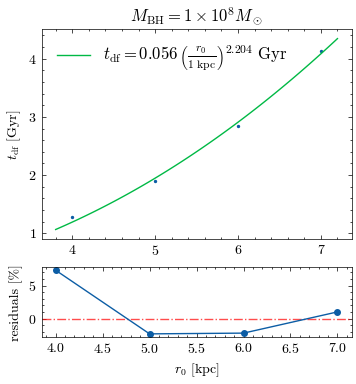

In [8]:
xx = np.linspace(3.8, 7.2, 100)

fig, ax = plt.subplots(2, 1, figsize = (4, 4), gridspec_kw={'height_ratios': [3, 1]})
ax[0].scatter(r, t_r , marker='o', s = 2)
ax[0].plot(xx, t_fit(xx, r_A, r_B), c = 'C1', label = r'$t_\mathrm{{df}} = {:.{p}f} \, \left( \frac{{r_0}}{{1 \,\, \mathrm{{kpc}}}} \right)^{{{:.{p}f}}} \, \, \mathrm{{Gyr}} $'.format(r_A, r_B, p=3))
ax[0].set_ylabel(r'$t_\mathrm{df}$ [Gyr]')
ax[0].legend(fontsize = 12, loc='best')
ax[0].set_title(r'$M_\mathrm{BH} = 1 \times 10^8 M_\odot$')

ax[1].axhline(0, ls = '-.', c = 'r', alpha = 0.7)
ax[1].plot(r, residuals, 'o-', markersize = 4)
ax[1].set_ylabel('residuals [%]')
ax[1].set_xlabel(r'$r_0$ [kpc]')
#plt.savefig('plots/r_fit_01.png', dpi = 400)
plt.show()

In [9]:
r_par_7, r_cov_7 = curve_fit(t_fit, r_7, t_r_7)

r_A_7, r_B_7 = r_par_7
print('Cov. matrix condition number = ', np.linalg.cond(r_cov_7), ', diag. elements = ', np.diag(r_cov_7))

Cov. matrix condition number =  1826.2960150205959 , diag. elements =  [0.00018271 0.00557811]


In [10]:
residuals_7 = 100 * (t_r_7 - t_fit(r_7, r_A_7, r_B_7)) / t_fit(r_7, r_A_7, r_B_7)

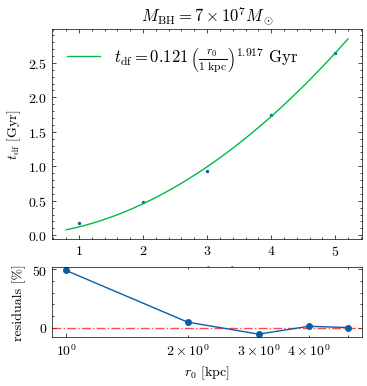

In [11]:
xx_7 = np.linspace(0.8, 5.2, 100)

fig, ax = plt.subplots(2, 1, figsize = (4, 4), gridspec_kw={'height_ratios': [3, 1]})
ax[0].scatter(r_7, t_r_7 , marker='o', s = 2)
ax[0].plot(xx_7, t_fit(xx_7, r_A_7, r_B_7), c = 'C1', label = r'$t_\mathrm{{df}} = {:.{p}f} \, \left( \frac{{r_0}}{{1 \,\, \mathrm{{kpc}}}} \right)^{{{:.{p}f}}} \, \, \mathrm{{Gyr}} $'.format(r_A_7, r_B_7, p=3))
ax[0].set_ylabel(r'$t_\mathrm{df}$ [Gyr]')
ax[0].set_xlabel(r'$r_\mathrm{BH}$ [kpc]')
ax[0].legend(fontsize = 12, loc='best')
ax[0].set_title(r'$M_\mathrm{BH} = 7 \times 10^7 M_\odot$')

ax[1].axhline(0, ls = '-.', c = 'r', alpha = 0.7)
ax[1].plot(r_7, residuals_7, 'o-', markersize = 4)
ax[1].set_ylabel('residuals [%]')
ax[1].set_xlabel(r'$r_0$ [kpc]')
ax[1].semilogx()
#plt.savefig('plots/r_fit_007.png', dpi = 400)
plt.show()

In [12]:
residuals_7[0]

np.float64(49.10587706809208)

### t_df vs mass

In [13]:
max = len(M)
max

11

In [14]:
M_par, M_cov = curve_fit(t_fit, M[:max], t_M[:max])

M_A, M_B = M_par
print('Cov. matrix condition number = ', np.linalg.cond(M_cov), ', diag. elements = ', np.diag(M_cov))


Cov. matrix condition number =  3958.899396729812 , diag. elements =  [0.00017733 0.0051578 ]


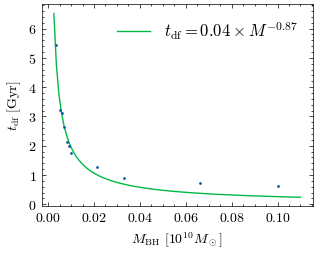

In [15]:
xx = np.linspace(0.0025, 0.11, 100)

plt.errorbar(M, t_M, marker='o', markersize=1, ls = '')
plt.plot(xx, t_fit(xx, M_A, M_B), label = r'$t_\mathrm{{df}} = {:.{p}f} \times M^{{{:.{p}f}}}$'.format(M_A, M_B, p=2))
plt.xlabel(r'$M_\mathrm{BH}$ [10$^{10} M_\odot$]')
plt.ylabel(r'$t_\mathrm{df}$ [Gyr]')
plt.legend(fontsize = 12, loc='best')
#plt.savefig('fit.png')
plt.show()


Text(0.5, 0, '$M_\\mathrm{BH}$ [10$^{10} M_\\odot$]')

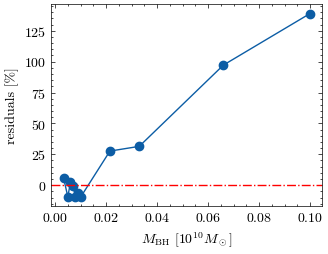

In [16]:
residuals = 100 * (t_M - t_fit(M, M_A, M_B)) / t_fit(M, M_A, M_B)
plt.plot(M, residuals, 'o-')
plt.axhline(0, ls = '-.', c = 'r')
plt.ylabel('residuals [%]')
plt.xlabel(r'$M_\mathrm{BH}$ [10$^{10} M_\odot$]')

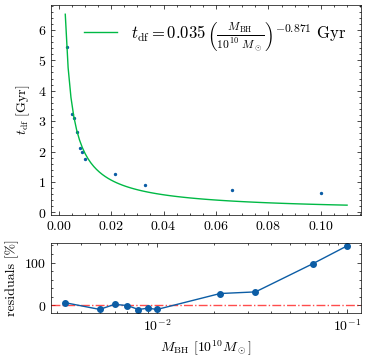

In [17]:
fig, ax = plt.subplots(2, 1, figsize = (4, 4), gridspec_kw={'height_ratios': [3, 1]})
ax[0].scatter(M, t_M , marker='o', s = 2)
ax[0].plot(xx, t_fit(xx, M_A, M_B), c = 'C1', label = r'$t_\mathrm{{df}} = {:.{p}f} \, \left( \frac{{M_\mathrm{{BH}}}}{{10^{{10}} \,\, M_\odot}} \right)^{{{:.{p}f}}} \, \, \mathrm{{Gyr}} $'.format(M_A, M_B, p=3))
ax[0].set_ylabel(r'$t_\mathrm{df}$ [Gyr]')
ax[0].legend(fontsize = 12, loc='best')

ax[1].axhline(0, ls = '-.', c = 'r', alpha = 0.7)
ax[1].plot(M, residuals, 'o-', markersize = 4)
ax[1].set_ylabel('residuals [%]')
ax[1].set_xlabel(r'$M_\mathrm{BH}$ [10$^{10} M_\odot$]')
ax[1].semilogx()
#plt.savefig('plots/M_fit_0.png', dpi = 400)
plt.show()